In [8]:
#Code cell adapted from 1d_energy_comparison.ipynb in the pvqz_basis_set_comparison folder
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
from scipy.optimize import curve_fit
hartree_to_cm = 219474.6313705

def load_coords_energy(file_name):
    """loads in unsorted basis set energy files"""
    #sort file by coordinates first
    energy_file = np.loadtxt(file_name)
    sort_idx = np.argsort(energy_file[:,7])
    energy_file = energy_file[sort_idx]
    
    #convert hartree to wavenumber, set minimum
    energy_file[:,6] = energy_file[:,6]*hartree_to_cm
    energy_file[:,6] = energy_file[:,6] - min(energy_file[:,6])
    
    #separate coords and energy
    return (energy_file[:,:6], energy_file[:,6])

(-0.5, 1000.0)

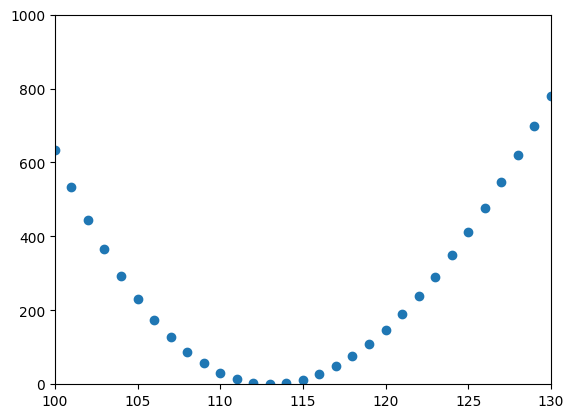

In [58]:
apoh_coords, E_apoh = load_coords_energy('apoh_1d.txt')
apoh = apoh_coords[:,4]*np.pi/180
w = (np.tanh(-0.008*(E_apoh - 2000)) + 1.002002002) / 2.002002002
#print(apoh)
#print(E_apoh)

plt.figure()
plt.plot(apoh*180/np.pi, E_apoh, 'o')
plt.xlim(100,130)
plt.ylim(-0.5, 1000)

[9.94007296e+03 2.00852646e+00]


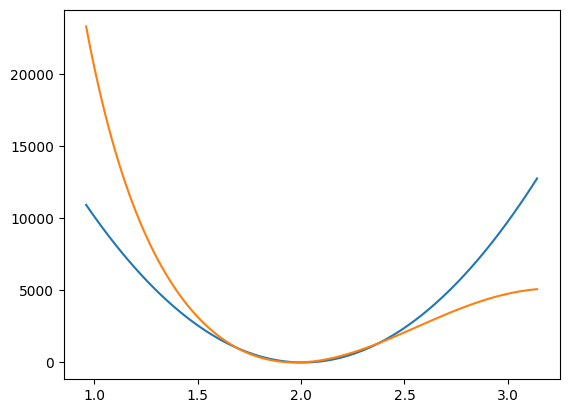

In [60]:
popt, pcov = curve_fit(lambda x, a, xe: a*(x-xe)**2, apoh, E_apoh, 
                       [10000, 1.97],
                       sigma = 1/w
                       )
print(popt)

plt.figure()
plt.plot(apoh, (lambda x, a, xe: a*(x-xe)**2)(apoh, popt[0], popt[1]))
plt.plot(apoh, E_apoh)

[7.18020714e+05 1.36152818e-01 1.97515009e+00]


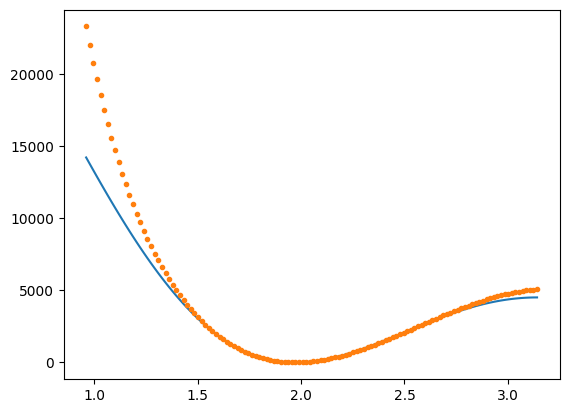

In [72]:
w = (np.tanh(-0.008*(E_apoh - 3000)) + 1.002002002) / 2.002002002
popt, pcov = curve_fit(lambda x, a, b, xe: a*(1-np.exp(b*(np.cos(x)-np.cos(xe))))**2, apoh, E_apoh, 
                       [10000, 1.5, 1.97],
                       sigma = 1/w
                       )
print(popt)

predict_apoh = (lambda x, a, b, xe: 
                a*(1-np.exp(b*(np.cos(x)-np.cos(xe))))**2)(apoh, popt[0], popt[1], popt[2])
plt.figure()
plt.plot(apoh, predict_apoh)
plt.plot(apoh, E_apoh, '.')

61.180255318857036


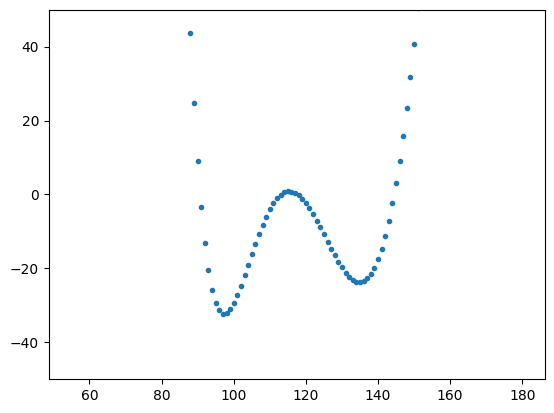

In [81]:
plt.figure()
plt.plot(apoh*180/np.pi, E_apoh-predict_apoh, '.')
plt.ylim(-50,50)

print(np.sqrt(np.sum(((E_apoh-predict_apoh)*(np.sqrt(w)))**2)/len(E_apoh)))